In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('/content/gdrive/MyDrive/Machine Leaning Models Implications /Linear Regression /USA house price.xlsx')

In [6]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'country'],
      dtype='object')

**Independent and Dependents Variables**

In [7]:
y = df['price']
x = df[['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated']]

In [8]:
# Convert 'date' to datetime format
df["date"] = pd.to_datetime(df["date"])

# Extract useful parts of the date
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month
df["sale_day"] = df["date"].dt.day  # optional (not always needed)

# Drop the original 'date' column (since it's no longer useful as text)
df = df.drop(columns=["date"])

# Define dependent & independent variables
y = df["price"]

X = df[[
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
    "floors", "waterfront", "view", "condition", "sqft_above",
    "sqft_basement", "yr_built", "yr_renovated",
    "sale_year", "sale_month"

]]


**Train and Test**

In [9]:
from sklearn.model_selection import train_test_split

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (3680, 14)
Testing set size: (920, 14)


**Scale the Features**

In [10]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Applying regression models**

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#initilizing the model
lr_model = LinearRegression()
#train model
lr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [12]:
y_pred = lr_model.predict(X_test_scaled)


**Evaluate model performance**

In [13]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MSE:", mse)
print("MAE:", mae)
print("R² Score:", r2)


Linear Regression Results:
MSE: 986577422039.7091
MAE: 211012.8839049454
R² Score: 0.03262150065117553


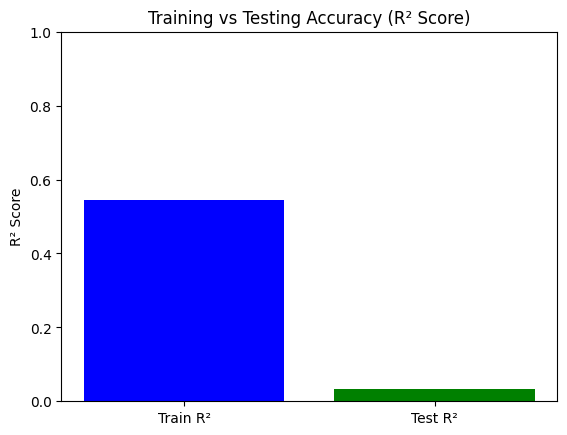

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# R² for training and testing
train_r2 = r2_score(y_train, lr_model.predict(X_train_scaled))
test_r2 = r2_score(y_test, y_pred)

# Bar plot
plt.bar(["Train R²", "Test R²"], [train_r2, test_r2], color=["blue", "green"])
plt.ylabel("R² Score")
plt.title("Training vs Testing Accuracy (R² Score)")
plt.ylim(0, 1)  # keeps the scale between 0 and 1
plt.show()


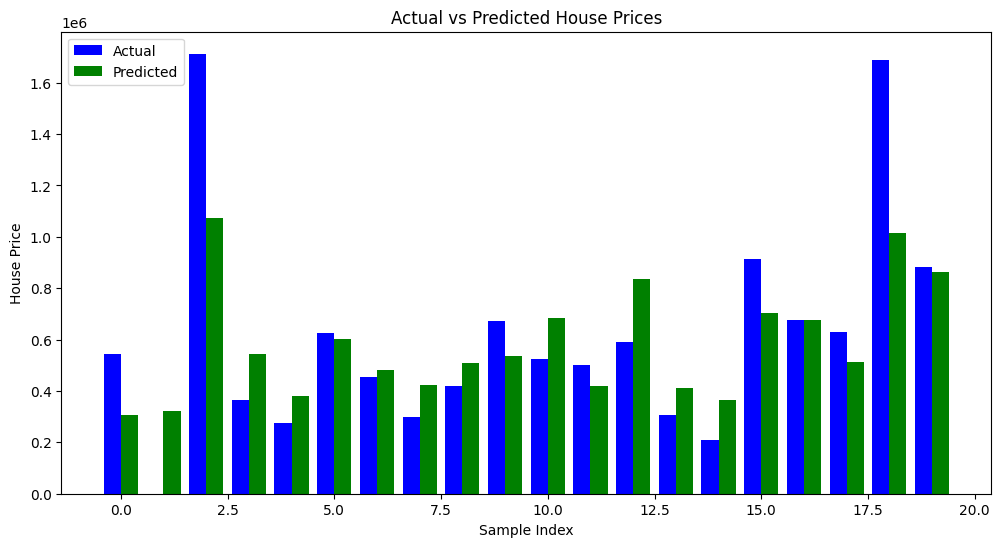

In [ ]:

# Take a small sample to plot (e.g., first 20 predictions)
n = 20
actual = y_test[:n].values
predicted = y_pred[:n]

# Set up bar positions
x = np.arange(n)

# Plot bars
plt.figure(figsize=(12,6))
plt.bar(x - 0.2, actual, width=0.4, label="Actual", color="blue")
plt.bar(x + 0.2, predicted, width=0.4, label="Predicted", color="green")

plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()


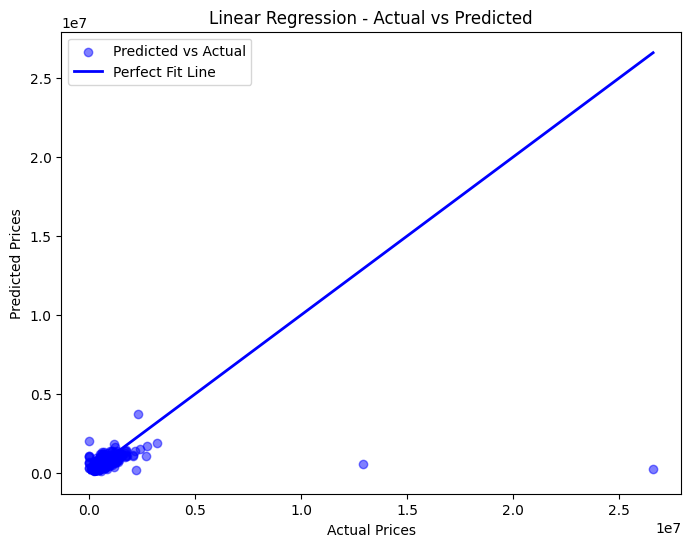

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="blue", linewidth=2, label="Perfect Fit Line")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression - Actual vs Predicted")
plt.legend()
plt.show()


**Ridge Regression Model**

In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Initialize the Ridge model
ridge_regressor = Ridge()

In [20]:
ridge_regressor

Ridge()

In [21]:
Parameter={'alpha': [1,2,5,10,20,30,40,50,60,70,80,90,100]}
RidgeCV = GridSearchCV(estimator=ridge_regressor, param_grid=Parameter, cv=5)
RidgeCV.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90,
                                   100]})

In [22]:
print(RidgeCV.best_params_)

{'alpha': 100}


In [23]:
print(RidgeCV.best_score_)

0.5330839078281917


In [24]:
ridge_pred = RidgeCV.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


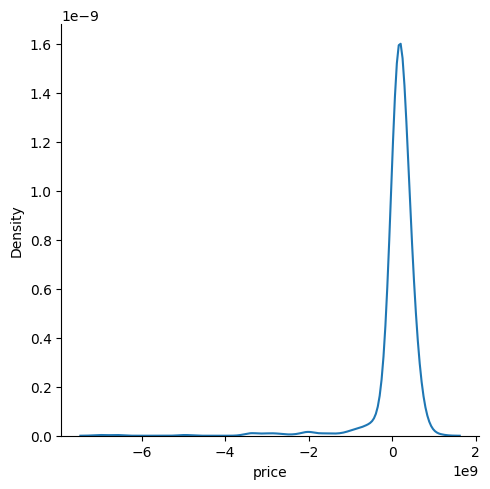

In [26]:
sns.displot(ridge_pred-y_test, kind='kde')

In [27]:
score = r2_score(ridge_pred,y_test)
print(score)

-0.035929496176914766


**Lasso Regression**

In [28]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Initialize the Lasso model
lasso = Lasso()

In [33]:
Parameter={'alpha': [1,2,5,10,20,30,40,50,60,70,80,90,100]}
lassoCV = GridSearchCV(lasso, Parameter, scoring= "neg_mean_squared_error", cv=5)
lassoCV.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.080e+13, tolerance: 4.360e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.688e+13, tolerance: 4.102e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.262e+13, tolerance: 4.215e

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90,
                                   100]},
             scoring='neg_mean_squared_error')

In [34]:
print(lassoCV.best_params_)
print(lassoCV.best_score_)

{'alpha': 1}
-66141116646.79285


In [36]:
lasso_pred = lassoCV.predict(X_test)

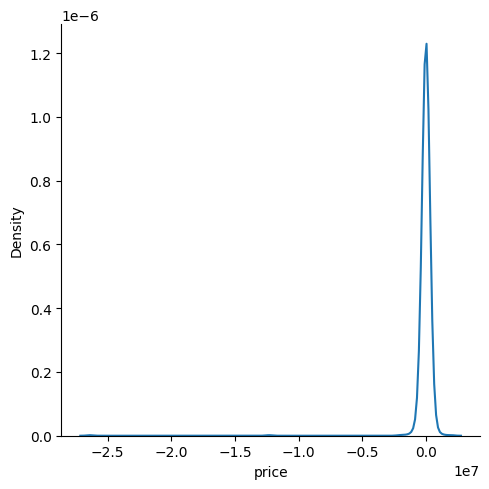

In [39]:
sns.displot(lasso_pred-y_test, kind='kde')